# Framing the problem

Outdoor activities like mountaineering and hiking have seen increasing popularity in recent years. With more people spending time in the outdoors and, for example, looking to the wilderness for sustenance during backpacking or foraging as a hobby, it is important that people have the correct tools to do these things safely.

**Goal**: Classify a mushroom as poisonous or edible based on a variety of observed characterstics



# Getting the data

In [ ]:
# install the UCI ML repository

!pip install ucimlrepo

# retrieve the UCI mushroom dataset and separate the data into features and targets

from ucimlrepo import fetch_ucirepo
mushroom = fetch_ucirepo(id=73)

x = mushroom.data.features
y = mushroom.data.targets

display(x)
display(y.value_counts())

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


,count
poisonous,
e,4208
p,3916


# Exploratory data analysis

## Finding "useless" features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import math

# creating dataframe and taking our first look at the data

df = x.copy()
df['class'] = y.values.ravel() # ravel to convert a 2D array into 1D

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())
print("\nUnique values per feature:")
print(df.nunique().sort_values())


Shape: (8124, 23)

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Unique values per feature:
veil-type                    1
bruises                      2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
gill-attachment              2
class                        2
ring-number                  3
stalk-surface-below-ring     4
stalk-root                   4
cap-surface                  4
stalk-surface-above-ring     4
veil-color                   4
ring-type                    5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


We can see from taking a look at the number of unique values each feature has that `veil-type` only has one, meaning we can easily exclude it from the set of features we'll be training the model on.

## Looking the edible/poisonous distribution of the dataset

In [ ]:
# check how many edible and poisonous

print(df['class'].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


This looks like a pretty good dataset to train with, since we've got an almost even number of samples for each classification category.

## Checking for features with a large number of null values

In [ ]:
# check for missing values
null_counts = x.isnull().sum()
null_percentages = (null_counts / len(x)) * 100
total_nulls = null_counts.sum()

null_summary = pd.DataFrame({
    'Total Null Count': null_counts,
    'Percentage': null_percentages.round(2)
})
print(null_summary)
print(f"Total NA values in dataset: {total_nulls}")

                          Total Null Count  Percentage
cap-shape                                0        0.00
cap-surface                              0        0.00
cap-color                                0        0.00
bruises                                  0        0.00
odor                                     0        0.00
gill-attachment                          0        0.00
gill-spacing                             0        0.00
gill-size                                0        0.00
gill-color                               0        0.00
stalk-shape                              0        0.00
stalk-root                            2480       30.53
stalk-surface-above-ring                 0        0.00
stalk-surface-below-ring                 0        0.00
stalk-color-above-ring                   0        0.00
stalk-color-below-ring                   0        0.00
veil-type                                0        0.00
veil-color                               0        0.00
ring-numbe

By checking the dataset for null values, we were able to identify that the feature `stalk-root` is missing about 30% of its entries.

However, since our objective is to identify a mushrooms toxicity based on physical characteristics, we'll use a correlation matrix and crosstab analysis to evaluate the usefulness of the `stalk-root` feature one more time before deciding to discard it.

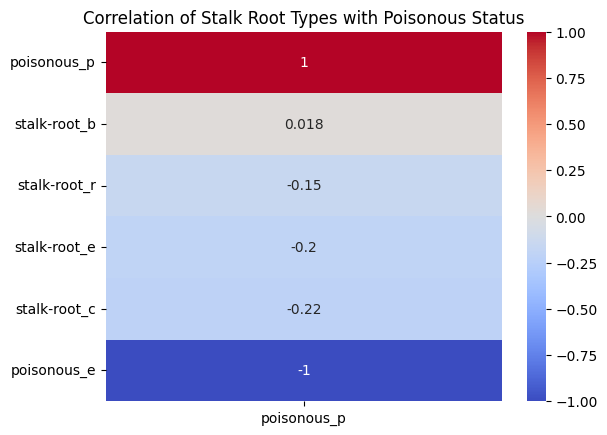

Crosstab Analysis:

class          e     p
stalk-root            
b           1920  1856
c            512    44
e            864   256
missing      720  1760
r            192     0


/tmp/ipykernel_142539/425729367.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.loc['stalk-root'] = x['stalk-root'].fillna('unknown')


In [ ]:
# build a dataframe with just the 'stalk-root' feature
corr_df = pd.concat(
    [y, x['stalk-root']],
    axis = 1
)

# compute correlations
corr_matrix_data = pd.get_dummies(corr_df)

corr_matrix = corr_matrix_data.corr()

# use correlations to create and display a heatmap for analysis
sns.heatmap(
    corr_matrix[['poisonous_p']].sort_values(by = 'poisonous_p', ascending = False),
    annot = True,
    cmap='coolwarm'
)
plt.title('Correlation of Stalk Root Types with Poisonous Status')
plt.show()

# crosstab analysis
print("Crosstab Analysis:\n")
print(
    pd.crosstab(df['stalk-root'].fillna('missing'),
    df['class'])
)

# missing values are treated as 'unknown'
x.loc['stalk-root'] = x['stalk-root'].fillna('unknown')

While the correlation matrix shows a weak relationship between a mushroom's toxicity and the stalk root type, the crosstab analysis shows that the feature is significant in terms of identification. We can see that the `r` category is a clear indicator of edibility, and that the `missing` category is heavily skewed towards poisonous samples.

We'll choose to treat the missing values as their own category rather than discarding the feature altogether.

## Examining distributions per feature to identify strong and weak indicators

We'll construct countplots for each feature separately to see which features are more likely to indicate an edible or poisonous mushroom, so we can prioritize them in the data preparation stage accordingly.

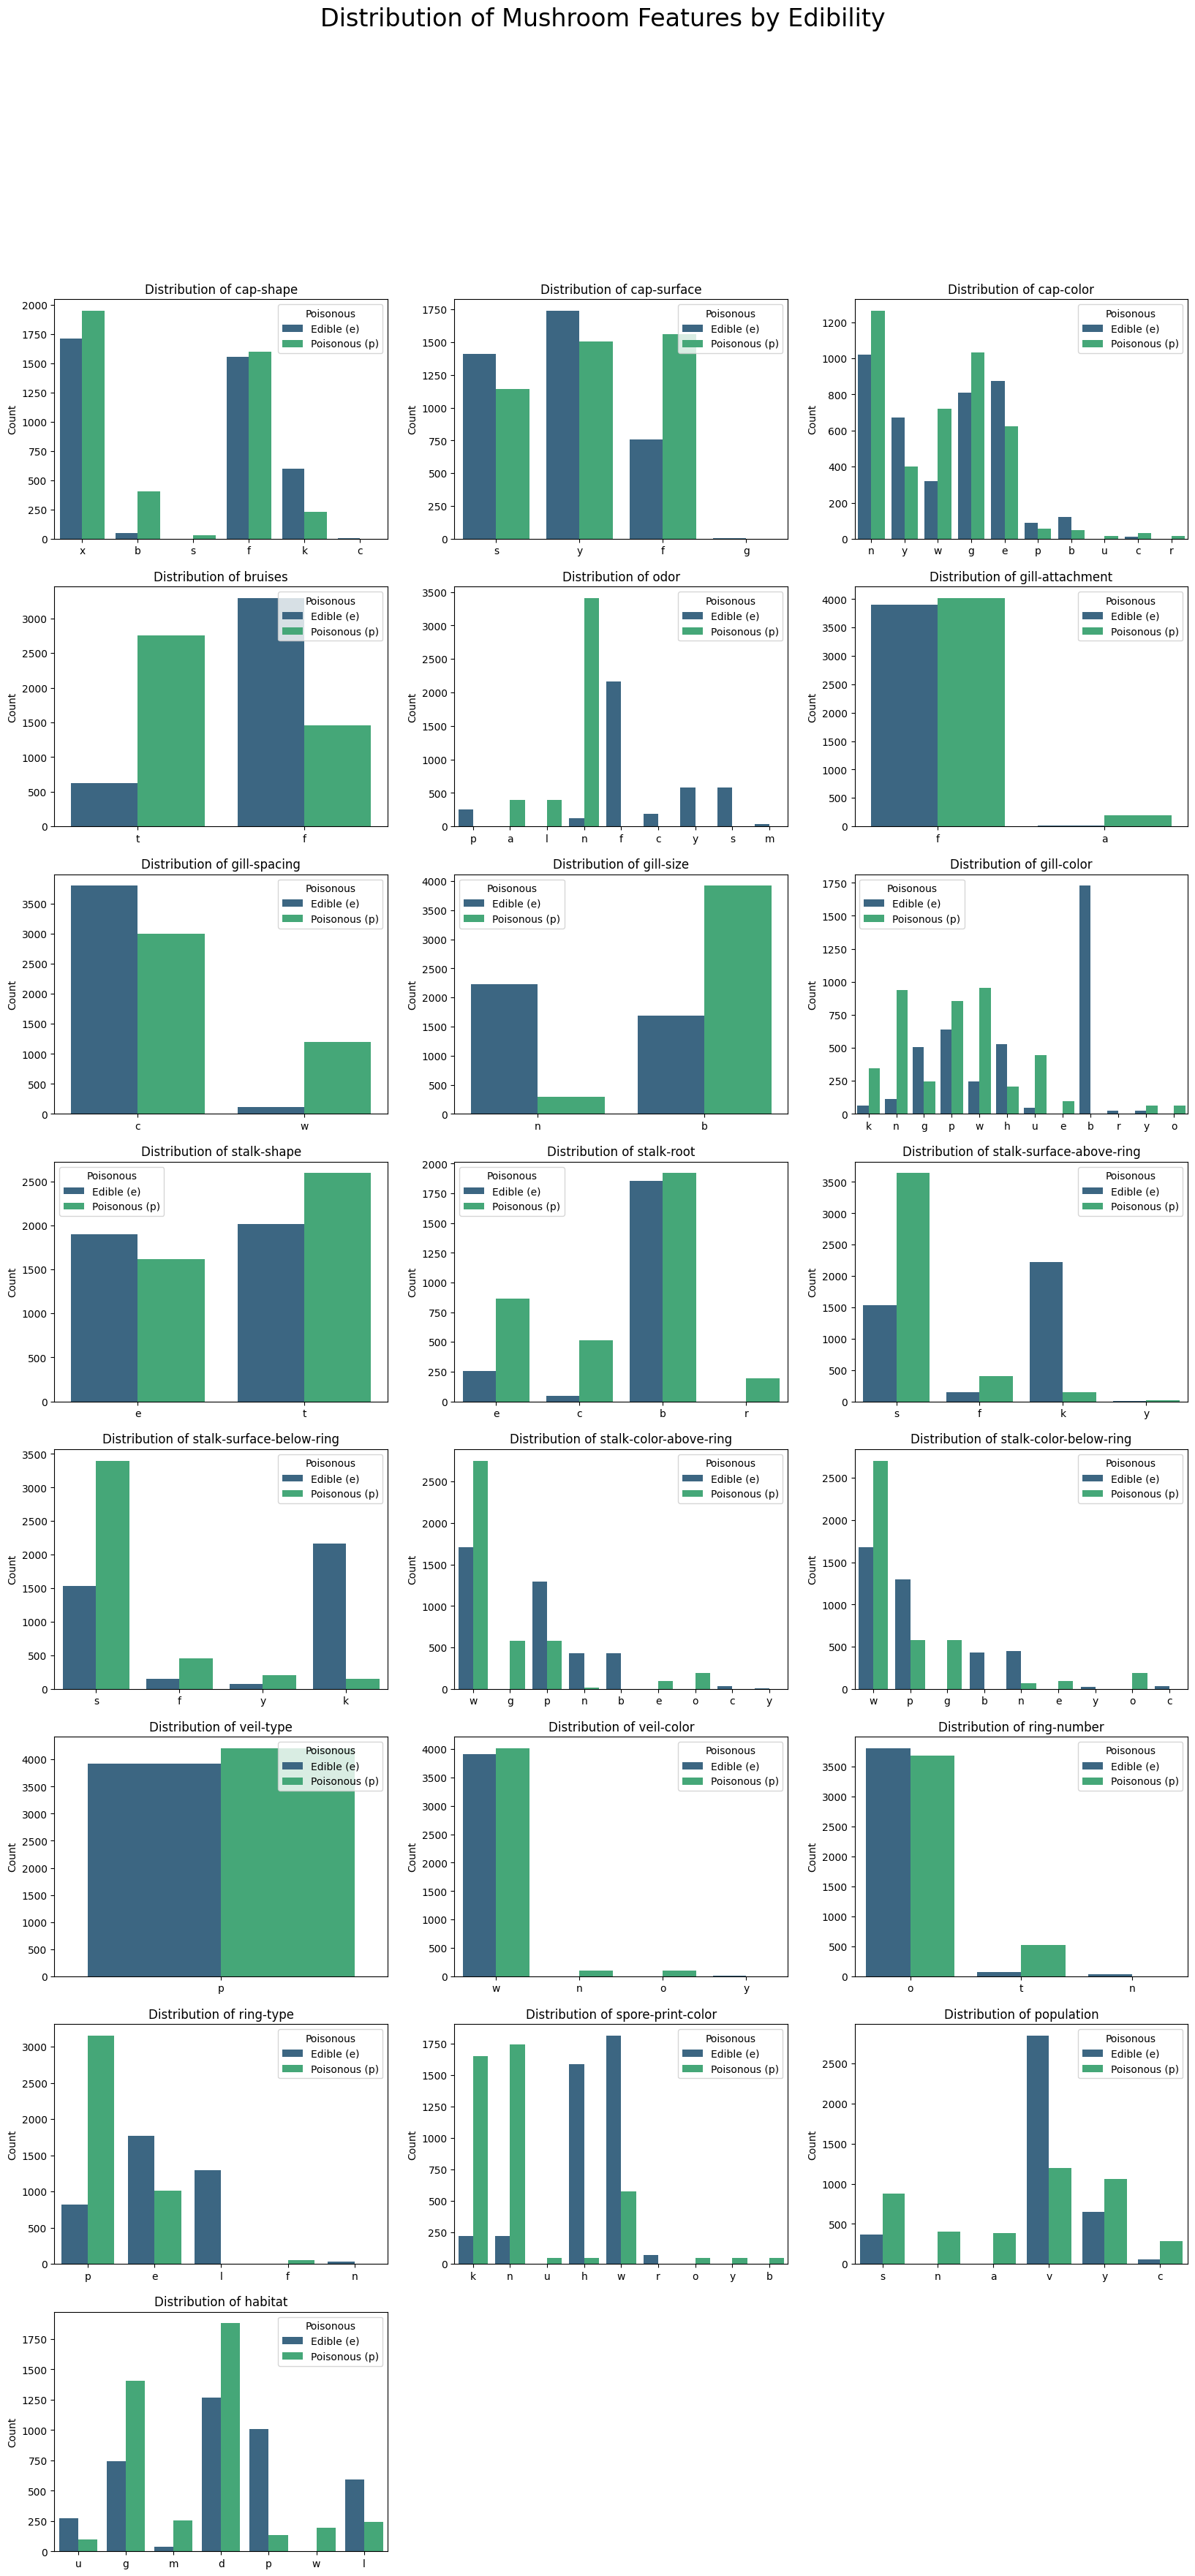

In [ ]:
# create temporary dataframe for EDA
df_eda = pd.concat(
    [x,y],
    axis = 1
)

# specify how many columns we want for the plots
cols = x.columns
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize = (20, n_rows * 5)
)

fig.suptitle(
    'Distribution of Mushroom Features by Edibility',
    fontsize = 24
)

# for loop that iterates through each feature to generate a grid of countplots
for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]
    sns.countplot(
        data = df_eda,
        x = col,
        hue = 'poisonous',
        ax = ax,
        palette = 'viridis'
    )
    ax.set_title(
        f'Distribution of {col}',
        fontsize = 12,
        y = 1
    )
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(
        title='Poisonous',
        labels=['Edible (e)', 'Poisonous (p)']
    )

# second for loop that deletes the empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.show()

With the grid of countplots, we can easily determine which features indicate edibility by looking for strong differences in `edible` and `poisonous` distributions.

From the distributions we can see...

- **Strong indicators:** `bruises` `odor` `gill-size` `ring-type` `spore-print-color`

- **Moderate indicators:** `cap-surface` `cap-color` `gill-spacing` `stalk-root` `gill-color` `stalk-surface-above-ring`  `stalk-surface-below-ring` `stalk-color-above-ring` `stalk-color-below-ring` `population` `habitat`

- **Weak indicators:** `cap-shape` `gill-attachment` `stalk-shape` `veil-color` `ring-number`

- **Excluded:** `veil-type`

Since our dataset isn't excessively large, we don't have to completely ignore the weaker indicators fo the sake of efficiency. We'll simply keep in mind each feature's impact during the next step.

# Preparing the data for our model

## Why We Chose the Decision Tree Classifier

We opted to use a **decision tree classifier** for this project because it fits the structure and goals of our application well.

Our application asks users to provide different mushroom characteristics, and the model evaluates those characteristics one step at a time before making a prediction. Decision trees work in the same way by checking features in sequence and following a path from the root of the tree to a final outcome. Because of this, the model aligns naturally with the way our input data is organized.

Another advantage is that decision trees are easy to understand and visualize. The model can be displayed as a diagram that clearly shows which features are being used and the order in which decisions are made. This level of transparency is important in a project where understanding the reasoning behind a prediction matters just as much as the prediction itself for user safety.

Decision trees also allow us to explain why a prediction was made. Since determining whether a mushroom is edible or poisonous can come with serious consequences, it is important to see how the model reached its conclusion. By tracing the path through the tree, both users and developers can better understand and trust the result.

The model is also well suited for categorical data. The UCI mushroom dataset is made entirely of categorical features like cap shape, odor, and gill color. Although we use one hot encoding so the data can be processed with scikit-learn, decision trees still perform very effectively with this type of feature based data.

## Cleaning the data

### Define features and target (edible/poisonous classification)

In [ ]:
STRONG_FEATURES = [
    "bruises", "odor", "gill-size", "ring-type",
    "spore-print-color"
]

MODERATE_FEATURES = [
"cap-surface", "cap-color", "gill-spacing",
"stalk-root", "gill-color", "stalk-surface-above-ring",
"stalk-surface-below-ring", "stalk-color-above-ring",
"stalk-color-below-ring", "population", "habitat"
]

WEAK_FEATURES = [
    "cap-shape", "gill-attachment", "stalk-shape",
    "veil-color", "ring-number"
]

EXCLUDE_FEATURES = [
    "veil-type"
]

TARGET = "class"


### Exclude useless features

In [ ]:
df = df.drop(columns=EXCLUDE_FEATURES, errors="ignore")
print(f"Dropped {EXCLUDE_FEATURES}")

Dropped ['veil-type']


### Handle missing values

For features that are strong indicators, we will replace the missing values with a custom `unknown` category. For the rest of the features, we will simply replace them with the mode.

In [ ]:
# replace '?' columns in UCI dataset with actual null values
df.replace('?', np.nan, inplace=True)

for col in STRONG_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')
print(f"Missing values in strong features replaced.")

REMAINING_FEATURES = MODERATE_FEATURES + WEAK_FEATURES

for col in REMAINING_FEATURES:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
print(f"Missing values in moderate/weak features replaced.")

print(f"Rows remaining: {len(df)}")
print("Missing values remaining:", df.isnull().sum().sum())

Missing values in strong features replaced.
Missing values in moderate/weak features replaced.
Rows remaining: 8124
Missing values remaining: 0


## Split data into training and test sets

In [ ]:
from sklearn.model_selection import train_test_split

# encode target before splitting
df[TARGET] = df[TARGET].map({"e": 0, "p": 1})

y = df[TARGET]
x = df.drop(columns=[TARGET])

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# check
print(f"Train size: {len(x_train)}, Test size: {len(x_test)}")
print("Train class balance:\n", y_train.value_counts(normalize=True).round(2))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(2))

Train size: 6499, Test size: 1625
Train class balance:
 class
0    0.52
1    0.48
Name: proportion, dtype: float64
Test class balance:
 class
0    0.52
1    0.48
Name: proportion, dtype: float64


## Encoding features

Using the categorizations we found earlier through EDA, we'll **target encode** the strong indicators, and **one-hot encode** the rest.

In [ ]:
import json # for streamlit

# Save target encoding mappings BEFORE encoding x_train
target_encoding_maps = {}
for col in STRONG_FEATURES:
    means = x_train.assign(target=y_train).groupby(col)['target'].mean()
    target_encoding_maps[col] = means.to_dict()

print("Mappings saved:") # for streamlit
for col, mapping in target_encoding_maps.items():
    print(f"\n{col}:")
    for k, v in mapping.items():
        print(f"  {k} -> {v:.4f}")

Mappings saved:

bruises:
  f -> 0.6941
  t -> 0.1845

odor:
  a -> 0.0000
  c -> 1.0000
  f -> 1.0000
  l -> 0.0000
  m -> 1.0000
  n -> 0.0343
  p -> 1.0000
  s -> 1.0000
  y -> 1.0000

gill-size:
  b -> 0.3059
  n -> 0.8839

ring-type:
  e -> 0.6337
  f -> 0.0000
  l -> 1.0000
  n -> 1.0000
  p -> 0.2058

spore-print-color:
  b -> 0.0000
  h -> 0.9715
  k -> 0.1127
  n -> 0.1142
  o -> 0.0000
  r -> 1.0000
  u -> 0.0000
  w -> 0.7550
  y -> 0.0000


In [ ]:
# target encoding
for col in STRONG_FEATURES:
    means = pd.Series(target_encoding_maps[col])
    x_train[col] = x_train[col].map(means)
    x_test[col] = x_test[col].map(means)

# one-hot encoding
x_train = pd.get_dummies(x_train, columns=REMAINING_FEATURES)
x_test = pd.get_dummies(x_test, columns=REMAINING_FEATURES)

# realign columns
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

# checks
assert list(x_train.columns) == list(x_test.columns), "Column mismatch"
assert x_train.isnull().sum().sum() == 0, "Null values in x_train"
assert x_test.isnull().sum().sum() == 0, "Null values in x_test"
print(f"Final feature count: {x_train.shape[1]}")

Final feature count: 93


In [ ]:
# for streamlit
ohe_columns = x_train.columns.tolist()

encoding_data = {
    "target_encoding_maps": target_encoding_maps,
    "ohe_columns": ohe_columns,
    "strong_features": STRONG_FEATURES,
    "remaining_features": REMAINING_FEATURES
}

with open("encoding_data.json", "w") as f:
    json.dump(encoding_data, f)

print("encoding_data.json saved.")

encoding_data.json saved.


# Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(x_train, y_train)

print("Model trained successfully.")
print(f"Number of training samples: {x_train.shape[0]}")
print(f"Number of test samples: {x_test.shape[0]}")

Model trained successfully.
Number of training samples: 6499
Number of test samples: 1625


# Fine-tuning the model

## Recall as a metric

When tuning this model, we optimize for recall rather than accuracy or precision.

Recall measures how many mushrooms the model correctly identifies as poisonous. In other words, it minimizes false positive cases where the model **predicts a mushroom "edible" that is actually poisonous**, which can be extremely dangerous for users and should be avoided at all costs.

Because the cost of the two types of errors is so unequal, recall is the right metric to prioritize.

## Performing grid search to fine-tune

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best recall score:", round(grid_search.best_score_, 4))

classifier = grid_search.best_estimator_

Best parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1}
Best recall score: 0.9994


# Evaluation and performance

As the final step, we'll see how the trained and fine-tuned classifier performs on the unseen test set we created earlier in the data preparation stage.

Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



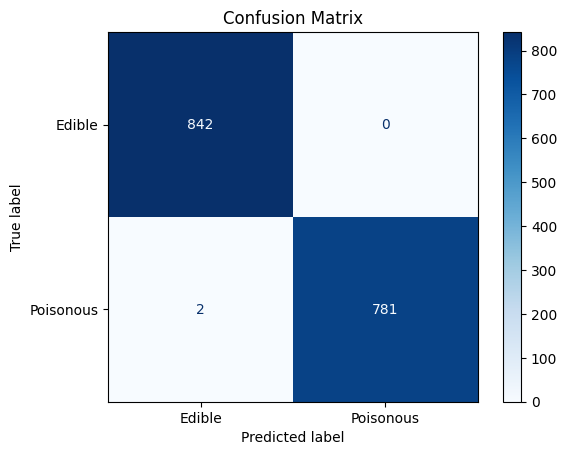

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# generate predictions on the test set
y_pred = classifier.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Edible", "Poisonous"]))

# generate confusion matrix for easier visual analysis
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Edible", "Poisonous"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The classification tells us four things:

- **Precision**: How many of the mushrooms that the model predicted poisonous actually were poisonous?
- **Recall**: How many poisonous mushrooms was the model able to catch? Remember that this is the metric we prioritized during fine-tuning.
- **F1-score**: Recall and precision combined into a single value.
- **Accuracy**: Percentage of all correct classifications, positive and negative.

The confusion matrix gives us a clearer look at the true and false negatives and positives the model produced.

### Results and Analysis

We can see that our classifer did an excellent job. An **overwhelming majority (1,623 out of 1,625, or ~0.99%)** of test samples were correctly identified.

However, there were **two cases where a poisonous mushroom was incorrectly identified as edible**. This doesn't show up in the classification report, since it's such a small amount and scores have been rounded. However, like mentioned earlier, this could definitely be a concern, since the presence of false positives could make the model unsafe for people to use.

If we were to go back and make some changes to our model during the earlier stages, some ways we could try and fix this issue are:

- **Selecting a different model**: Maybe a different classifier, like a random forest, could be more effective?
- **Prioritize features differently:** If we take a look at the two false positive cases, are there certain features that caused the misclassification? Could these be moved to a stronger or weaker category to fix the model's performance?

In the future, we might build on this project by creating a more advanced version that classifies pictures of mushrooms with their features and/or species, and then using that information to classify the specimen as poisonous or edible. However, with the computing limitations we had, we decided classifying based on provided characteristics would be more feasible for this project.

# Saving and deploying the model

We'll save our trained classifier as a `.pkl` file so it can be used in our `streamlit` app.

In [ ]:
import joblib

joblib.dump(classifier, "mushroom_model.pkl")
print("Model saved as mushroom_model.pkl")

Model saved as mushroom_model.pkl


See the [Github repository](https://github.com/ssanrey/Mushroom-Classification) for the app and a demonstration video.